In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

In [2]:
df = pd.read_csv("data/narraciones_maya_campeche.csv")

df.head(5)

,Unnamed: 0,name,dur
0,0,01_Anatolio_Pech,396.930625
1,1,02_Liboria_May,417.018813
2,2,03_Eligio_Uicab_Jatswooj,465.893875
3,3,04_Alfonso_Tamay,672.496313
4,4,05_Felipe_May,827.506938


In [3]:
df_spk = pd.read_csv("data/spk_metadata.csv")
df_spk.head(5)

,spk_id,description,sexo,nombre
0,spk_001,canal: filosofia maya,mujer,NaN
1,spk_002,canal: lengua cultura maya yucateca,hombre,NaN
2,spk_003,canal: lengua cultura maya yucateca,hombre,NaN
3,spk_004,canal: lengua cultura maya yucateca,mujer,NaN
4,spk_005,canal: lengua maya yucateco con maestro pat,hombre,NaN


In [4]:
def map_name(item):
    name = item["name"][3:10]
    founded = df_spk[df_spk[" description"].str.contains(name)].iloc[0]
    spk_id = founded["spk_id"]
    return spk_id

In [5]:
df["spk_id"] = df.apply(map_name, axis=1)

df

,Unnamed: 0,name,dur,spk_id
0,0,01_Anatolio_Pech,396.930625,spk_019
1,1,02_Liboria_May,417.018813,spk_020
2,2,03_Eligio_Uicab_Jatswooj,465.893875,spk_021
3,3,04_Alfonso_Tamay,672.496313,spk_022
4,4,05_Felipe_May,827.506938,spk_023
5,5,06_Gricelda_Pech,434.599188,spk_024
6,6,07_Eligio_Uicab_Tomojchi,498.860438,spk_021
7,7,08_Teodoro_May,1234.703688,spk_025
8,8,09_Adolfo_Chuc,672.000000,spk_026
9,9,10_Jesus_Euan,615.993500,spk_027


In [6]:
df_cleaned = df[["spk_id", "dur"]].sort_values(by="spk_id").groupby("spk_id").sum().reset_index()
df_cleaned

,spk_id,dur
0,spk_019,396.930625
1,spk_020,417.018813
2,spk_021,964.754313
3,spk_022,672.496313
4,spk_023,827.506938
5,spk_024,434.599188
6,spk_025,1234.703688
7,spk_026,672.000000
8,spk_027,615.993500
9,spk_028,305.475938


In [7]:
df_cleaned["dur"].sum() // 60 // 60

np.float64(3.0)

In [8]:
from datetime import timedelta

def format_duration(m):    
    return f"{m:.1f} m"

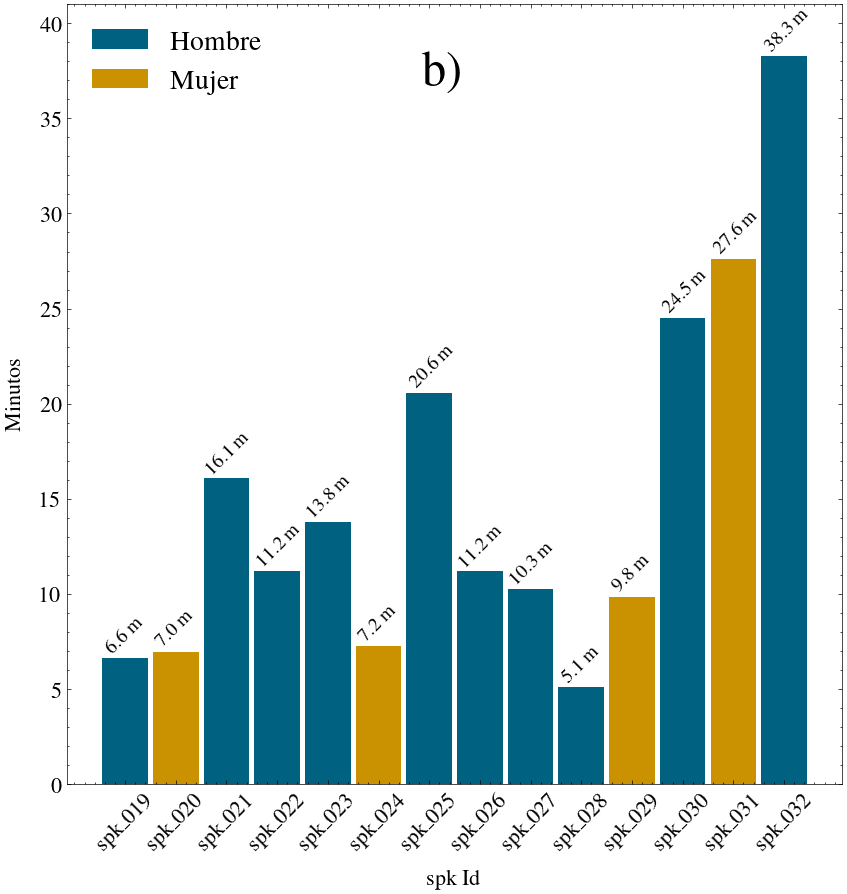

In [17]:
plt.figure(figsize=(10,10))
female_color = "#CA9100"
male_color = "#006181"
with plt.style.context(['science', 'ieee']):
    # Create bars
    barWidth = 0.9
    
    bars = df_cleaned["dur"].values / 60
    r = df_cleaned["spk_id"].values
    
    # Crear mapeo de colores basado en sexo
    # Primero, crear un diccionario que relacione spk_id con sexo
    sex_map = dict(zip(df_spk['spk_id'], df_spk[' sexo']))
    
    # Definir colores para cada sexo
    colors = []
    for spk in r:
        if sex_map.get(spk) == 'hombre':
            colors.append(male_color)  # Azul turquesa (groupB)
        else:
            colors.append(female_color)  # Verde (groupC)
    
    # Create barplot
    plt.bar(r, bars, width = barWidth, color=colors)
    # Note: the barplot could be created easily. See the barplot section for other examples.
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=male_color, label='Hombre'),
        Patch(facecolor=female_color, label='Mujer'),
    ]
    plt.legend(handles=legend_elements, fontsize=20)
    
    # Text below each barplot with a rotation at 45°
    plt.xticks(rotation=45, size=16)
    plt.yticks(size=16)
    
    # Text on the top of each bar
    for i in range(len(r)):
        plt.text(x=i - 0.45, y=bars[i] + 0.3, s=format_duration(bars[i]), fontsize=14, rotation=45)
        #plt.text(x = r[i]-0.5 , y = bars[i]+0.1, s = label[i], size = 6)

    # Adjust the margins
    plt.subplots_adjust(bottom= 0.2, top = 0.98)
    
    # Show graphic
    plt.text(0.5, 0.91, "b)", fontsize=35, transform=plt.gcf().transFigure, ha='center', va='center')
    plt.ylim(0, 41)
    plt.ylabel("Minutos", size=16, labelpad=11)
    plt.xlabel("spk Id", size=16, labelpad=11)
    plt.savefig("./figures/narraciones_count.svg", bbox_inches='tight', pad_inches=0)
    plt.show()